# 03 — Root-Cause Exploration & Investigation Prioritization

**Project:** Purchase-to-Pay Process Mining & Exception Intelligence

## Objective

This notebook uses the case-level analytical model from Notebook 2 to investigate where delays, exceptions, and process complexity are concentrated.

The analysis focuses on:

- vendor-level exception rates,
- spend-area performance,
- document-type patterns,
- P2P matching/process categories,
- process variants,
- cycle-time outliers,
- resource complexity,
- Pareto concentration,
- and transparent case-investigation prioritization.

> **Important:** This is root-cause exploration, not proof of causation. Segment differences are treated as evidence for investigation, not proof that a vendor, employee, or business unit caused an outcome.


## 1. Load the case-level analytical model

Expected local project path:

```text
data/processed/p2p_case_level.csv
```

The generated case-level dataset remains local and is excluded from GitHub.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

candidates = [
    Path("../data/processed/p2p_case_level.csv"),
    Path("data/processed/p2p_case_level.csv"),
    Path("/mnt/data/p2p_case_level.csv"),
]

CASE_PATH = next((p for p in candidates if p.exists()), None)
if CASE_PATH is None:
    raise FileNotFoundError(
        "Run 02_process_analysis.ipynb first to generate p2p_case_level.csv"
    )

case_df = pd.read_csv(
    CASE_PATH,
    parse_dates=["case_start", "case_end"],
    low_memory=False
)

# Notebook 2 exported the repeated-activity count but not the binary flag.
# Derive it here explicitly so the rule remains reproducible.
if "repeated_activity_flag" not in case_df.columns:
    case_df["repeated_activity_flag"] = (
        case_df["repeated_activity_count"].gt(0)
    ).astype("int8")

print(f"Using: {CASE_PATH.resolve()}")
print(f"Rows: {len(case_df):,}")
print(f"Columns: {case_df.shape[1]}")
print(f"Unique cases: {case_df['case:concept:name'].nunique():,}")


Using: /mnt/data/p2p_case_level.csv
Rows: 251,734
Columns: 40
Unique cases: 251,734


## 2. Define the analysis population

Cases carrying the historical timestamp-anomaly flag are preserved in the case model but excluded from duration comparisons so they do not distort cycle-time analysis.


In [2]:
analysis_df = case_df.loc[
    case_df["timestamp_anomaly_flag"].eq(0)
].copy()

print(f"All cases: {len(case_df):,}")
print(f"Cycle-time analysis population: {len(analysis_df):,}")
print(f"Excluded from duration comparisons: {len(case_df) - len(analysis_df):,}")


All cases: 251,734
Cycle-time analysis population: 251,656
Excluded from duration comparisons: 78


## 3. Build a transparent exception-signal count

Included case-level signals:

- PO modification,
- PO intervention,
- invoice reversal,
- goods-receipt reversal,
- payment-block handling,
- repeated activity.

This is a **process-complexity / investigation signal count**. It is not a fraud, supplier-risk, or compliance score.


In [3]:
signal_cols = [
    "po_modification_flag",
    "po_intervention_flag",
    "invoice_reversal_flag",
    "gr_reversal_flag",
    "payment_block_handling_flag",
    "repeated_activity_flag",
]

analysis_df["exception_signal_count"] = analysis_df[signal_cols].sum(axis=1)

analysis_df["any_exception_signal_flag"] = (
    analysis_df["exception_signal_count"] > 0
).astype("int8")

signal_distribution = (
    analysis_df["exception_signal_count"]
    .value_counts()
    .sort_index()
    .rename_axis("exception_signal_count")
    .reset_index(name="cases")
)

signal_distribution["case_share_pct"] = (
    signal_distribution["cases"] / len(analysis_df) * 100
).round(2)

display(signal_distribution)


,exception_signal_count,cases,case_share_pct
0,0,153406,60.96
1,1,75726,30.09
2,2,16313,6.48
3,3,5172,2.06
4,4,945,0.38
5,5,93,0.04
6,6,1,0.00


## 4. Long-cycle and high-handoff thresholds

Thresholds are derived from the actual data distribution rather than invented external benchmarks.

- `long_cycle_flag`: cycle time at or above P90
- `high_handoff_flag`: resource handoffs at or above P90

These are review thresholds only.


In [4]:
long_cycle_threshold = analysis_df["cycle_time_days_raw"].quantile(0.90)
high_handoff_threshold = analysis_df["resource_handoff_count"].quantile(0.90)

analysis_df["long_cycle_flag"] = (
    analysis_df["cycle_time_days_raw"] >= long_cycle_threshold
).astype("int8")

analysis_df["high_handoff_flag"] = (
    analysis_df["resource_handoff_count"] >= high_handoff_threshold
).astype("int8")

print(f"P90 cycle-time threshold: {long_cycle_threshold:,.2f} days")
print(f"P90 handoff threshold: {high_handoff_threshold:,.0f} handoffs")
print(f"Long-cycle cases: {analysis_df['long_cycle_flag'].sum():,}")
print(f"High-handoff cases: {analysis_df['high_handoff_flag'].sum():,}")


P90 cycle-time threshold: 126.08 days
P90 handoff threshold: 6 handoffs
Long-cycle cases: 25,197
High-handoff cases: 29,353


## 5. Reusable segment-performance function

Every segment is assessed using both **volume and rate** because a high exception count may simply reflect high transaction volume.


In [5]:
def segment_performance(data, segment):
    out = (
        data.groupby(segment, dropna=False)
        .agg(
            cases=("case:concept:name", "size"),
            median_cycle_days=("cycle_time_days_raw", "median"),
            p90_cycle_days=("cycle_time_days_raw", lambda s: s.quantile(0.90)),
            any_exception_rate=("any_exception_signal_flag", "mean"),
            po_modification_rate=("po_modification_flag", "mean"),
            invoice_reversal_rate=("invoice_reversal_flag", "mean"),
            gr_reversal_rate=("gr_reversal_flag", "mean"),
            payment_block_handling_rate=("payment_block_handling_flag", "mean"),
            repeated_activity_rate=("repeated_activity_flag", "mean"),
            long_cycle_rate=("long_cycle_flag", "mean"),
            median_handoffs=("resource_handoff_count", "median"),
            median_events=("event_count", "median"),
        )
        .reset_index()
    )

    rate_cols = [c for c in out.columns if c.endswith("_rate")]
    for col in rate_cols:
        out[col] = (out[col] * 100).round(2)

    return out


## 6. Vendor-level analysis

For rate-based vendor ranking, the notebook uses a minimum of **100 cases** to reduce unstable results from tiny denominators.

The threshold is an analytical guardrail, not an industry benchmark.


In [6]:
vendor_perf = segment_performance(analysis_df, "vendor")

vendor_min_cases = 100
vendor_rankable = vendor_perf.loc[
    vendor_perf["cases"] >= vendor_min_cases
].copy()

print(f"Total vendors: {vendor_perf['vendor'].nunique():,}")
print(f"Vendors with >= {vendor_min_cases} cases: {len(vendor_rankable):,}")

display(
    vendor_rankable
    .sort_values(["any_exception_rate", "cases"], ascending=[False, False])
    .head(20)
)


Total vendors: 1,974
Vendors with >= 100 cases: 307


,vendor,cases,median_cycle_days,p90_cycle_days,any_exception_rate,po_modification_rate,invoice_reversal_rate,gr_reversal_rate,payment_block_handling_rate,repeated_activity_rate,long_cycle_rate,median_handoffs,median_events
230,vendorID_0230,256,78.71,97.54,100.00,0.00,0.00,0.00,0.00,100.00,0.39,21.00,180.50
364,vendorID_0364,246,1.00,2.71,100.00,0.41,0.41,2.03,0.41,100.00,0.41,6.00,33.00
471,vendorID_0471,242,0.00,0.00,100.00,0.00,0.00,1.65,0.00,99.59,0.83,6.00,43.00
472,vendorID_0472,244,0.01,0.02,99.59,0.00,0.82,1.23,0.00,99.59,1.23,30.00,164.50
363,vendorID_0363,240,0.00,1.00,99.58,0.00,0.42,0.42,0.42,99.58,0.42,4.00,22.00
365,vendorID_0365,240,0.00,0.00,98.33,0.00,0.00,1.67,0.42,98.33,0.42,2.00,13.00
234,vendorID_0234,214,0.03,0.06,98.13,0.00,0.93,0.47,0.00,98.13,1.40,18.00,266.00
473,vendorID_0473,220,0.00,0.00,97.27,0.45,0.00,0.91,0.00,97.27,2.27,4.00,16.00
235,vendorID_0235,255,0.00,0.00,97.25,0.39,1.18,0.39,0.00,97.25,2.35,6.00,37.00
470,vendorID_0470,373,106.60,142.51,95.17,1.07,11.53,6.97,17.43,94.91,16.62,5.00,19.00


### Vendor exception count vs exception rate

The first question is **who contributes the most exception cases?**  
The second is **who has the highest exception rate after accounting for volume?**

These are intentionally kept separate.


In [7]:
vendor_exception_counts = (
    analysis_df.groupby("vendor", dropna=False)
    .agg(
        cases=("case:concept:name", "size"),
        exception_cases=("any_exception_signal_flag", "sum")
    )
    .reset_index()
)

vendor_exception_counts["exception_rate_pct"] = (
    vendor_exception_counts["exception_cases"]
    / vendor_exception_counts["cases"]
    * 100
).round(2)

display(
    vendor_exception_counts
    .sort_values("exception_cases", ascending=False)
    .head(20)
)


,vendor,cases,exception_cases,exception_rate_pct
136,vendorID_0136,14471,7956,54.98
104,vendorID_0104,9817,5615,57.20
120,vendorID_0120,13564,3687,27.18
106,vendorID_0106,7231,3107,42.97
197,vendorID_0197,3055,2419,79.18
182,vendorID_0182,7250,2255,31.10
108,vendorID_0108,3902,1584,40.59
236,vendorID_0236,3374,1416,41.97
118,vendorID_0118,3911,1409,36.03
404,vendorID_0404,2550,1395,54.71


## 7. Spend-area analysis

Spend areas are compared using case volume, duration, exception rates, reversals, block handling, and long-cycle prevalence.


In [8]:
spend_perf = segment_performance(analysis_df, "spend_area")

display(
    spend_perf
    .sort_values("cases", ascending=False)
    .head(25)
)


,spend_area,cases,median_cycle_days,p90_cycle_days,any_exception_rate,po_modification_rate,invoice_reversal_rate,gr_reversal_rate,payment_block_handling_rate,repeated_activity_rate,long_cycle_rate,median_handoffs,median_events
10,Packaging,109194,80.05,128.10,39.96,11.54,1.39,0.64,26.44,6.16,12.12,4.00,5.00
13,Sales,65813,53.00,95.67,32.46,8.37,3.04,0.77,20.83,6.97,5.62,4.00,5.00
18,Trading & End Products,22281,59.20,156.69,44.38,24.28,5.18,1.41,15.87,11.27,17.21,4.00,5.00
0,Additives,18315,77.43,113.04,33.30,13.37,2.38,1.18,17.16,8.83,6.07,4.00,5.00
1,CAPEX & SOCS,6768,27.36,120.93,35.74,6.38,4.89,0.68,23.46,7.70,9.72,4.00,5.00
7,Logistics,5240,1.00,119.60,81.24,4.58,2.84,7.18,4.41,77.60,8.44,5.00,18.00
6,Latex & Monomers,5006,73.71,105.72,45.11,18.76,4.83,0.90,28.41,8.61,5.31,4.00,6.00
20,NaN,3287,52.63,109.97,59.54,31.94,1.06,2.49,17.68,7.61,4.90,4.00,5.00
9,Others,2635,51.25,105.96,37.91,16.62,4.36,1.97,15.45,8.77,5.65,4.00,5.00
14,Solvents,2629,74.66,115.35,38.15,14.53,4.64,0.95,22.78,7.84,7.57,4.00,5.00


## 8. Document-type analysis

Document types may represent structurally different procurement workflows. Differences are therefore interpreted as process-pattern differences, not automatically as poor performance.


In [9]:
document_perf = segment_performance(analysis_df, "document_type")

display(
    document_perf
    .sort_values("cases", ascending=False)
)


,document_type,cases,median_cycle_days,p90_cycle_days,any_exception_rate,po_modification_rate,invoice_reversal_rate,gr_reversal_rate,payment_block_handling_rate,repeated_activity_rate,long_cycle_rate,median_handoffs,median_events
2,Standard PO,248682,64.05,126.02,38.79,12.19,2.53,0.96,22.41,8.60,9.86,4.00,5.00
1,Framework order,1536,34.56,349.02,91.28,79.49,6.25,4.43,5.14,48.44,29.36,4.00,5.00
0,EC Purchase order,1438,64.47,208.65,26.70,7.79,4.03,1.18,8.48,19.68,16.13,5.00,12.00


## 9. P2P matching / item-category analysis

This comparison considers the structurally different matching processes present in the source data.


In [10]:
item_category_perf = segment_performance(analysis_df, "item_category")

display(
    item_category_perf
    .sort_values("cases", ascending=False)
)


,item_category,cases,median_cycle_days,p90_cycle_days,any_exception_rate,po_modification_rate,invoice_reversal_rate,gr_reversal_rate,payment_block_handling_rate,repeated_activity_rate,long_cycle_rate,median_handoffs,median_events
2,"3-way match, invoice before GR",220949,66.35,127.01,38.97,12.31,2.66,0.83,24.27,6.89,10.52,4.00,5.00
1,"3-way match, invoice after GR",15165,63.39,133.18,54.24,13.14,3.69,2.90,15.07,34.70,11.49,4.00,6.00
3,Consignment,14498,19.93,48.68,19.85,9.84,0.00,1.42,0.00,10.14,0.29,1.00,2.00
0,2-way match,1044,23.69,196.86,100.00,100.00,0.96,0.00,1.15,43.30,16.57,3.00,4.00


## 10. Process-variant concentration

Because there are many process variants, the ranking below only considers variants with at least 100 cases.

This prevents one-off sequences from dominating interpretation.


In [11]:
variant_root = (
    analysis_df.groupby("variant_id")
    .agg(
        cases=("case:concept:name", "size"),
        median_cycle_days=("cycle_time_days_raw", "median"),
        p90_cycle_days=("cycle_time_days_raw", lambda s: s.quantile(0.90)),
        any_exception_rate=("any_exception_signal_flag", "mean"),
        long_cycle_rate=("long_cycle_flag", "mean"),
        median_handoffs=("resource_handoff_count", "median"),
        median_events=("event_count", "median"),
    )
    .reset_index()
)

variant_root["any_exception_rate"] = (
    variant_root["any_exception_rate"] * 100
).round(2)
variant_root["long_cycle_rate"] = (
    variant_root["long_cycle_rate"] * 100
).round(2)

variant_min_cases = 100

display(
    variant_root.loc[variant_root["cases"] >= variant_min_cases]
    .sort_values(
        ["any_exception_rate", "median_cycle_days"],
        ascending=False
    )
    .head(25)
)


,variant_id,cases,median_cycle_days,p90_cycle_days,any_exception_rate,long_cycle_rate,median_handoffs,median_events
660,664,189,196.38,218.77,100.00,100.00,2.00,3.00
3702,3712,101,184.84,184.87,100.00,100.00,2.00,4.00
4707,4721,213,183.13,183.13,100.00,82.63,3.00,4.00
685,689,327,134.08,192.07,100.00,70.95,6.00,7.00
938,942,110,125.17,156.31,100.00,44.55,6.00,7.00
9022,9045,205,120.04,120.04,100.00,0.00,6.00,8.00
5860,5875,245,119.12,136.01,100.00,31.84,3.00,5.00
408,411,128,117.27,169.86,100.00,47.66,5.00,7.00
484,487,590,113.16,142.05,100.00,33.90,5.00,7.00
404,407,208,112.08,135.04,100.00,17.79,5.00,6.00


## 11. Pareto concentration by vendor

This asks how concentrated the absolute exception workload is across vendors.


In [12]:
pareto_vendor = (
    vendor_exception_counts
    .sort_values("exception_cases", ascending=False)
    .reset_index(drop=True)
)

total_exception_cases = pareto_vendor["exception_cases"].sum()

pareto_vendor["cumulative_exception_cases"] = (
    pareto_vendor["exception_cases"].cumsum()
)

pareto_vendor["cumulative_exception_share_pct"] = np.where(
    total_exception_cases > 0,
    pareto_vendor["cumulative_exception_cases"] / total_exception_cases * 100,
    0
)

vendors_to_80 = int(
    (pareto_vendor["cumulative_exception_share_pct"] < 80).sum() + 1
)

print(
    f"Vendors required to account for approximately 80% "
    f"of exception-signal cases: {vendors_to_80:,}"
)

display(pareto_vendor.head(20))


Vendors required to account for approximately 80% of exception-signal cases: 147


,vendor,cases,exception_cases,exception_rate_pct,cumulative_exception_cases,cumulative_exception_share_pct
0,vendorID_0136,14471,7956,54.98,7956,8.10
1,vendorID_0104,9817,5615,57.20,13571,13.81
2,vendorID_0120,13564,3687,27.18,17258,17.57
3,vendorID_0106,7231,3107,42.97,20365,20.73
4,vendorID_0197,3055,2419,79.18,22784,23.19
5,vendorID_0182,7250,2255,31.10,25039,25.48
6,vendorID_0108,3902,1584,40.59,26623,27.10
7,vendorID_0236,3374,1416,41.97,28039,28.54
8,vendorID_0118,3911,1409,36.03,29448,29.97
9,vendorID_0404,2550,1395,54.71,30843,31.39


## 12. Cycle time vs process complexity

Spearman correlation is used because the variables are skewed and relationships need not be linear.

> Correlation is not causation.


In [13]:
complexity_cols = [
    "cycle_time_days_raw",
    "event_count",
    "unique_activity_count",
    "unique_resource_count",
    "resource_handoff_count",
    "repeated_activity_count",
    "exception_signal_count",
]

spearman_corr = (
    analysis_df[complexity_cols]
    .corr(method="spearman")["cycle_time_days_raw"]
    .drop("cycle_time_days_raw")
    .sort_values(ascending=False)
    .rename("spearman_with_cycle_time")
    .to_frame()
)

display(spearman_corr)


,spearman_with_cycle_time
unique_activity_count,0.47
unique_resource_count,0.46
resource_handoff_count,0.44
event_count,0.42
exception_signal_count,0.16
repeated_activity_count,0.09


## 13. Investigation-priority framework

A transparent, explainable score is used to surface cases for human review.

| Signal | Points |
|---|---:|
| Long cycle (>= P90) | 2 |
| Invoice reversal | 2 |
| Goods-receipt reversal | 2 |
| PO modification | 1 |
| PO intervention | 1 |
| Payment-block handling | 1 |
| Repeated activity | 1 |
| High resource handoffs (>= P90) | 1 |

The score is only an **investigation-priority tool**.


In [14]:
analysis_df["investigation_priority_score"] = (
      2 * analysis_df["long_cycle_flag"]
    + 2 * analysis_df["invoice_reversal_flag"]
    + 2 * analysis_df["gr_reversal_flag"]
    + 1 * analysis_df["po_modification_flag"]
    + 1 * analysis_df["po_intervention_flag"]
    + 1 * analysis_df["payment_block_handling_flag"]
    + 1 * analysis_df["repeated_activity_flag"]
    + 1 * analysis_df["high_handoff_flag"]
)

analysis_df["investigation_priority"] = pd.cut(
    analysis_df["investigation_priority_score"],
    bins=[-1, 1, 3, np.inf],
    labels=["Low", "Medium", "High"]
)

priority_summary = (
    analysis_df["investigation_priority"]
    .value_counts(sort=False)
    .rename_axis("priority")
    .reset_index(name="cases")
)

priority_summary["case_share_pct"] = (
    priority_summary["cases"] / len(analysis_df) * 100
).round(2)

display(priority_summary)


,priority,cases,case_share_pct
0,Low,197765,78.59
1,Medium,41530,16.50
2,High,12361,4.91


## 14. Highest-priority cases

The output keeps all component flags visible so a reviewer can understand exactly why each case received its score.


In [15]:
priority_cols = [
    "case:concept:name",
    "vendor",
    "spend_area",
    "document_type",
    "item_category",
    "cycle_time_days_raw",
    "event_count",
    "resource_handoff_count",
    "po_modification_flag",
    "po_intervention_flag",
    "invoice_reversal_flag",
    "gr_reversal_flag",
    "payment_block_handling_flag",
    "repeated_activity_flag",
    "long_cycle_flag",
    "high_handoff_flag",
    "investigation_priority_score",
    "investigation_priority",
    "variant_id",
]

priority_cases = (
    analysis_df[priority_cols]
    .sort_values(
        ["investigation_priority_score", "cycle_time_days_raw"],
        ascending=[False, False]
    )
)

display(priority_cases.head(50))


,case:concept:name,vendor,spend_area,document_type,item_category,cycle_time_days_raw,event_count,resource_handoff_count,po_modification_flag,po_intervention_flag,invoice_reversal_flag,gr_reversal_flag,payment_block_handling_flag,repeated_activity_flag,long_cycle_flag,high_handoff_flag,investigation_priority_score,investigation_priority,variant_id
37711,4507011401_00010,vendorID_0136,Packaging,Standard PO,"3-way match, invoice before GR",169.14,13,9,1,1,1,1,1,1,1,1,11,High,3030
125,2000000100_00001,vendorID_0053,Marketing,EC Purchase order,"3-way match, invoice after GR",818.96,464,343,1,0,1,1,1,1,1,1,10,High,73
2058,4507000440_00010,vendorID_0207,Logistics,Framework order,"3-way match, invoice after GR",475.70,923,622,1,0,1,1,1,1,1,1,10,High,499
2040,4507000430_00010,vendorID_0201,Logistics,Framework order,"3-way match, invoice after GR",461.48,245,180,1,0,1,1,1,1,1,1,10,High,494
3247,4507000879_00110,vendorID_0388,Logistics,Framework order,"3-way match, invoice after GR",450.74,251,201,1,0,1,1,1,1,1,1,10,High,655
3238,4507000879_00020,vendorID_0388,Logistics,Framework order,"3-way match, invoice after GR",378.30,226,182,1,0,1,1,1,1,1,1,10,High,646
3239,4507000879_00030,vendorID_0388,Logistics,Framework order,"3-way match, invoice after GR",378.30,183,143,1,0,1,1,1,1,1,1,10,High,647
3240,4507000879_00040,vendorID_0388,Logistics,Framework order,"3-way match, invoice after GR",378.30,161,135,1,0,1,1,1,1,1,1,10,High,648
3242,4507000879_00060,vendorID_0388,Logistics,Framework order,"3-way match, invoice after GR",378.30,217,175,1,0,1,1,1,1,1,1,10,High,650
3243,4507000879_00070,vendorID_0388,Logistics,Framework order,"3-way match, invoice after GR",378.30,211,168,1,0,1,1,1,1,1,1,10,High,651


## 15. Visual summary — cycle time by process category

Values above the 99th percentile are excluded **from this chart only** to make the main distributions readable.


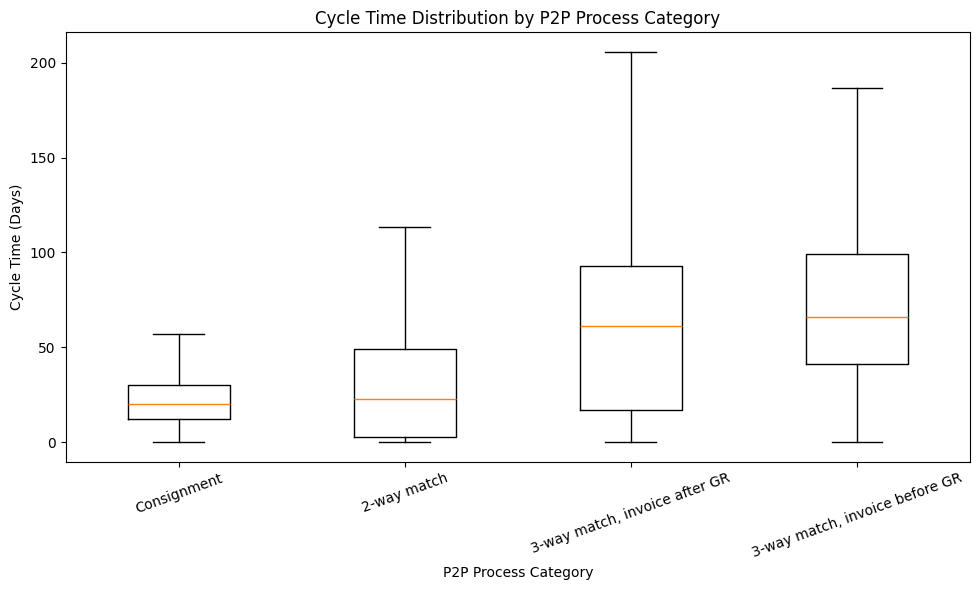

In [16]:
plot_df = analysis_df.loc[
    analysis_df["cycle_time_days_raw"]
    <= analysis_df["cycle_time_days_raw"].quantile(0.99)
].copy()

categories = (
    plot_df.groupby("item_category")["cycle_time_days_raw"]
    .median()
    .sort_values()
    .index
    .tolist()
)

data_for_plot = [
    plot_df.loc[
        plot_df["item_category"].eq(cat),
        "cycle_time_days_raw"
    ].dropna().values
    for cat in categories
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data_for_plot, tick_labels=categories, showfliers=False)
ax.set_title("Cycle Time Distribution by P2P Process Category")
ax.set_ylabel("Cycle Time (Days)")
ax.set_xlabel("P2P Process Category")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 16. Visual summary — vendor exception volume vs rate

Only vendors meeting the minimum-volume threshold are shown.


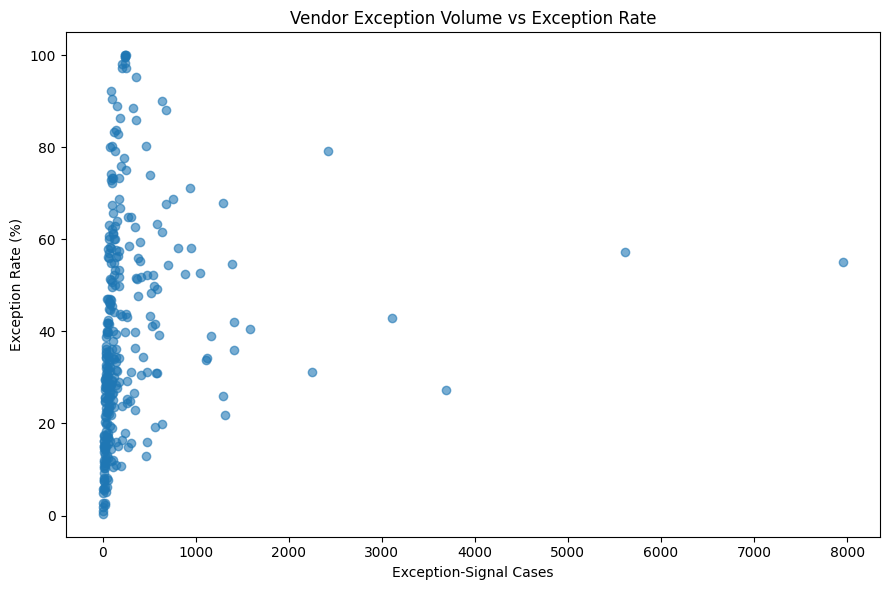

In [17]:
vendor_plot = vendor_exception_counts.loc[
    vendor_exception_counts["cases"] >= vendor_min_cases
].copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    vendor_plot["exception_cases"],
    vendor_plot["exception_rate_pct"],
    alpha=0.6
)
ax.set_title("Vendor Exception Volume vs Exception Rate")
ax.set_xlabel("Exception-Signal Cases")
ax.set_ylabel("Exception Rate (%)")
plt.tight_layout()
plt.show()


## 17. Export prioritized cases locally

This generated output can feed Excel and Power BI but should not be committed to GitHub.


In [18]:
preferred_output = Path("../data/processed/p2p_investigation_priority.csv")
fallback_output = Path("/mnt/data/p2p_investigation_priority.csv")

try:
    preferred_output.parent.mkdir(parents=True, exist_ok=True)
    priority_output = preferred_output
except PermissionError:
    priority_output = fallback_output

priority_cases.to_csv(priority_output, index=False)

print(f"Saved: {priority_output}")
print(f"Rows: {len(priority_cases):,}")


Saved: /mnt/data/p2p_investigation_priority.csv
Rows: 251,656


## 18. Conclusions and analytical boundaries

This notebook separates five management questions:

1. **Volume:** Which segments contribute the largest number of exception cases?
2. **Rate:** Which segments have elevated exception rates after accounting for volume?
3. **Duration:** Which process categories and variants are associated with longer cycle times?
4. **Complexity:** Which cases have more activities, repeated events, resources, or handoffs?
5. **Priority:** Which cases combine several transparent investigation signals?

The results do **not** prove:

- vendor fault,
- employee fault,
- supplier quality failure,
- non-compliance,
- fraud,
- financial loss,
- or causation.

The next technical phase is **SQL analysis**, where the same business logic and KPIs will be reproduced in SQL to demonstrate consistency and production-oriented analytical capability.
